**Angie Carolina Joya Duarte - 2322609**  

**Sheila Marcela Valencia Chito - 2243011**

## 1) Preparar el dataset

Importar librerías

In [55]:
import os
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Definir las semillas

In [56]:
semilla = 42
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

Leer dataset seleccionado: ibm.us.csv

In [57]:
path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0


### a) Graficar el promedio

In [58]:
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset["Date"] = pd.to_datetime(dataset["Date"])
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt,promedioDia
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0,6.37540
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0,6.36705
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0,6.36290
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0,6.25845
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0,6.12070


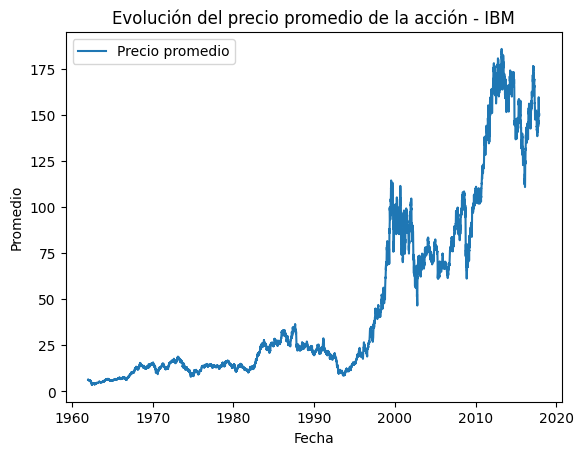

In [59]:
plt.plot(dataset["Date"], dataset["promedioDia"], label = "Precio promedio")
plt.title("Evolución del precio promedio de la acción - IBM")
plt.xlabel("Fecha")
plt.ylabel("Promedio")
plt.legend()
plt.show()

### b) Dividir los datos

In [60]:
#70% train, 15% validation, 15% test
n = len(dataset)

train = dataset[:int(n*0.7)][["promedioDia"]].to_numpy()
validation = dataset[int(n*0.7):int(n*0.85)][["promedioDia"]].to_numpy()
test = dataset[int(n*0.85):][["promedioDia"]].to_numpy()

print("Conjunto de entrenamiento: ",train[:5])
print("Conjunto de validación: ",validation[:5])
print("Conjunto de prueba: ",test[:5])

Conjunto de entrenamiento:  [[6.3754 ]
 [6.36705]
 [6.3629 ]
 [6.25845]
 [6.1207 ]]
Conjunto de validación:  [[96.151 ]
 [96.9425]
 [94.351 ]
 [94.384 ]
 [96.2135]]
Conjunto de prueba:  [[87.6125]
 [88.094 ]
 [85.8565]
 [84.6285]
 [84.332 ]]


### c) Normalizar los datos

Normalizar los datos

In [61]:
#Hallar la media y desviación del entrenamiento
media = train.mean()
desvest  = train.std()

#Normalizar los 3 subconjuntos respecto a los valores calculados
train = (train - media) / desvest
validation   = (validation   - media) / desvest
test  = (test  - media) / desvest

Creación de ventanas

In [62]:
#Ventanas de 30 días con muestras diarias
sampling_rate = 1
sequence_length = 15
delay = 1 
batch_size = 256

Preparar los dataset de acuerdo a la ventana de tiempo

In [63]:
train2D = train.reshape(-1, 1)
validation2D = validation.reshape(-1, 1)
test2D = test.reshape(-1, 1)

datasetTrain = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

datasetValidation = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
  )

datasetTest = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
  )

Funciones auxiliares para graficar

In [64]:
def graficaeMAE(history, titulo, ax=None):
  if ax is None:
    ax = plt.gca()

  loss = history.history["mae"]
  val_loss = history.history["val_mae"]
  epochs = range(1, len(loss) + 1)

  ax.plot(epochs, loss, "o-", label="MAE Entrenamiento")
  ax.plot(epochs, val_loss, "-", label="MAE Validación")
  ax.set_title(titulo)
  ax.set_xlabel("Época")
  ax.set_ylabel("MAE")
  ax.legend()

def graficarPrediccion(prediccion, y, titulo, ax=None):
  rango=(20, 70)
  
  if ax is None:
    ax = plt.gca()
        
  start, end = rango
  ax.plot(y[start:end], label="Valor Real")
  ax.plot(prediccion[start:end], label="Predicción")
  ax.set_title(titulo)
  ax.set_xlabel("Índice")
  ax.set_ylabel("Valor")
  ax.legend()

## 2) Modelo LSTM 

Definir arquitectura de la red

In [65]:
cantNeuronas = 16
epocas = 20

In [66]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas)(inputs) 
outputs = layers.Dense(1)(x)
LSTMBase = keras.Model(inputs, outputs)

Realizar el entrenamiento

In [67]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]
LSTMBase.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = LSTMBase.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=callbacks
)

print(f"MAE de las pruebas - LSTM: {LSTMBase.evaluate(datasetTest)[1]:.2f}")

Epoch 1/20


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3985 - mae: 0.2956 - val_loss: 1.6480 - val_mae: 1.1375
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1209 - mae: 0.1377 - val_loss: 0.4108 - val_mae: 0.4562
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0394 - mae: 0.0875 - val_loss: 0.1420 - val_mae: 0.3287
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0115 - mae: 0.0537 - val_loss: 0.0379 - val_mae: 0.1511
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - mae: 0.0433 - val_loss: 0.0209 - val_mae: 0.1045
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - mae: 0.0388 - val_loss: 0.0183 - val_mae: 0.0959
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - mae: 0.0373 - val_loss: 0.0173 - val_mae: 0.0939
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - mae: 0.0360 - val_loss: 0.0186 - val_mae: 0.1040
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - mae: 0.0351 

Evaluar los resultados

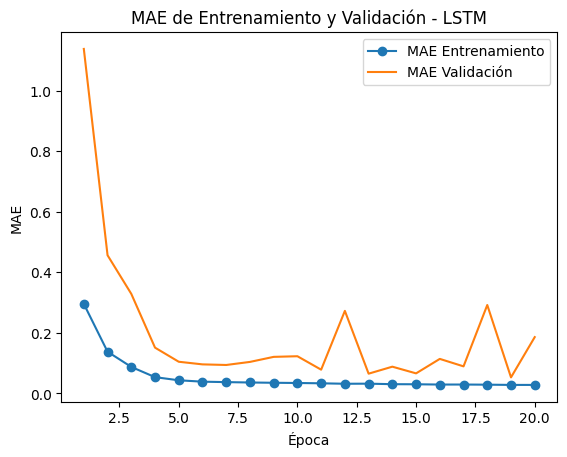

In [68]:
graficaeMAE(history, "MAE de Entrenamiento y Validación - LSTM")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


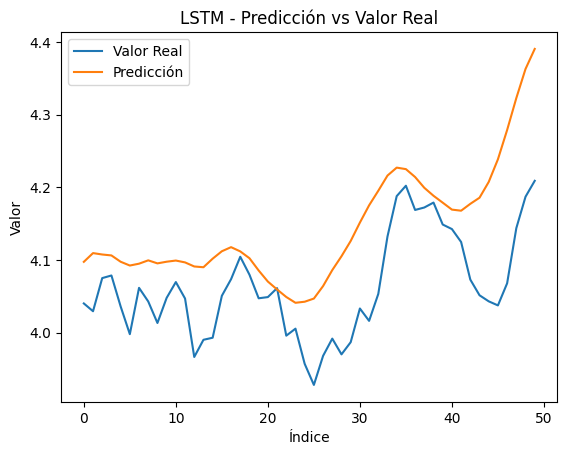

In [69]:
prediccion = LSTMBase.predict(datasetTest)
y = np.concatenate([y for x, y in datasetTest], axis=0)

graficarPrediccion(prediccion, y, "LSTM - Predicción vs Valor Real")

Modificando el número de neuronas


Entrenando modelo con 5 neuronas LSTM...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
MAE de prueba (5 neuronas): 2.2906

Entrenando modelo con 15 neuronas LSTM...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE de prueba (15 neuronas): 2.0191

Entrenando modelo con 30 neuronas LSTM...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE de prueba (30 neuronas): 2.0743


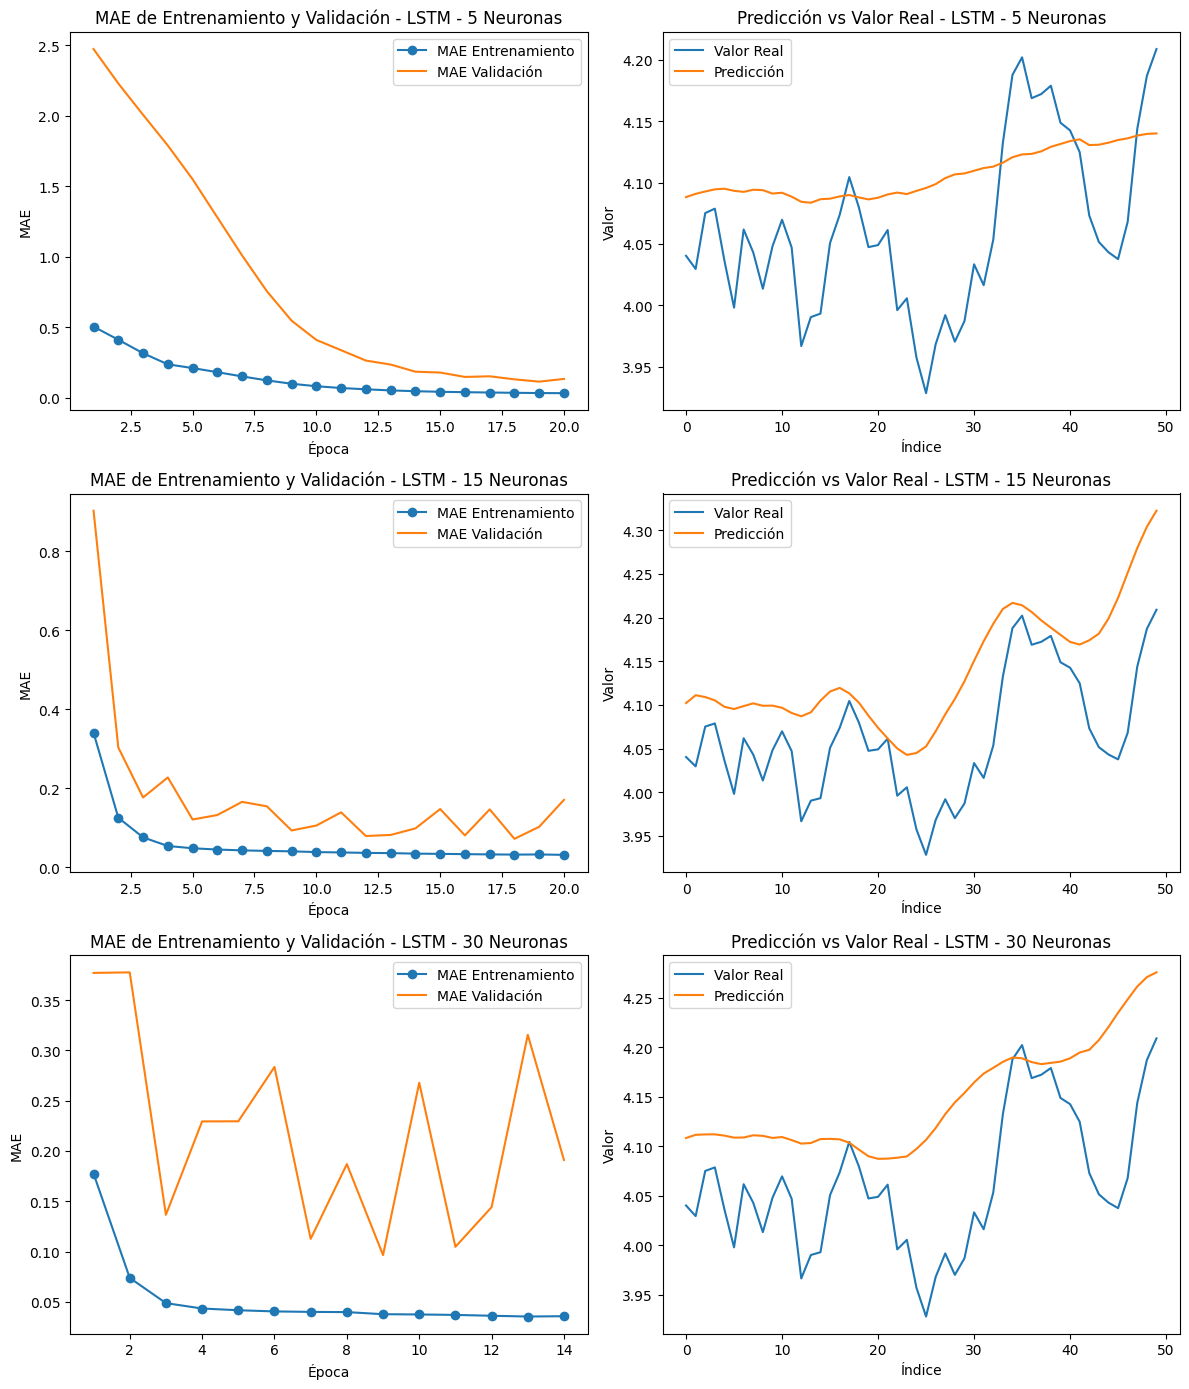

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

cantNeuronasLSTM = [5,15,30]

for i, n in enumerate(cantNeuronasLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.LSTM(n)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTest, verbose=0)[1]
  pred = modelo.predict(datasetTest)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {n} Neuronas", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {n} Neuronas", axes[i][1])

  print(f"MAE de prueba ({n} neuronas): {mae:.4f}")

plt.tight_layout()
plt.show()

Modificando el número de iteraciones

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
MAE de prueba (15 Épocas): 2.0286
Épocas realmente usadas: 15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE de prueba (50 Épocas): 2.8287
Épocas realmente usadas: 42
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE de prueba (100 Épocas): 2.3364
Épocas realmente usadas: 33


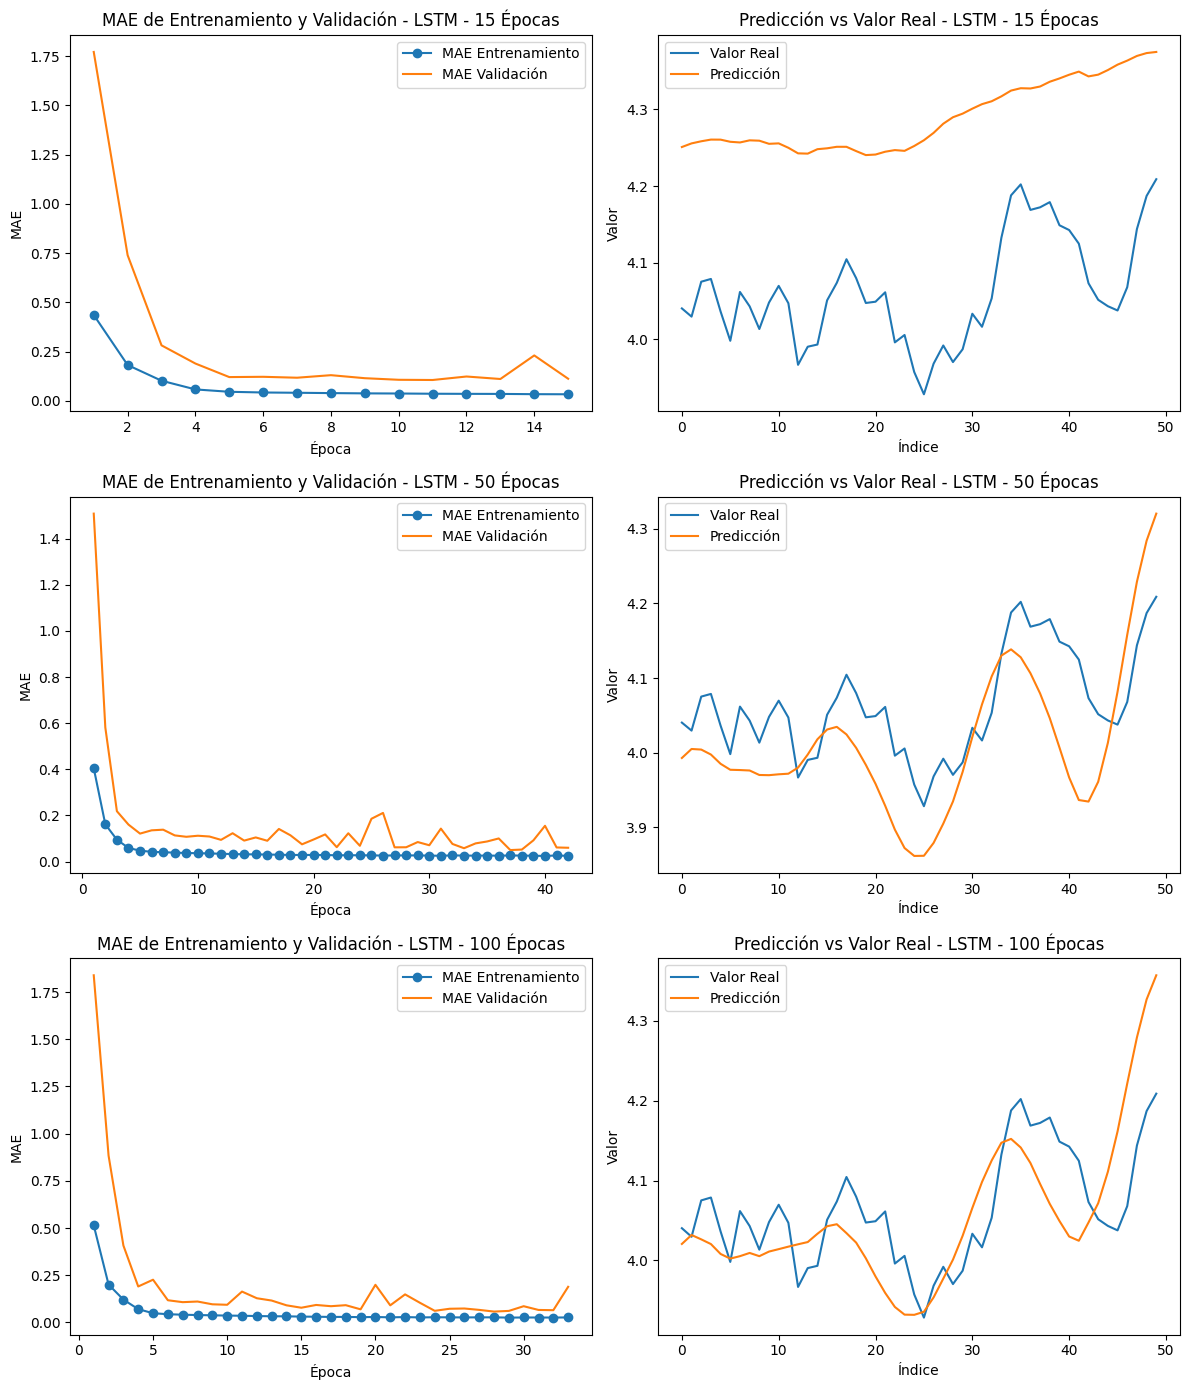

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

epocasLSTM = [15,50,100]

for i, n in enumerate(epocasLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Crear el modelo 
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrain,
    epochs=n,
    validation_data=datasetValidation,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTest, verbose=0)[1]
  pred = modelo.predict(datasetTest)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {n} Épocas", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {n} Épocas", axes[i][1])

  print(f"MAE de prueba ({n} Épocas): {mae:.4f}")
  print("Épocas realmente usadas:", len(history.history["loss"]))

plt.tight_layout()
plt.show()

Cambiando la ventana

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
MAE de prueba (Ventana de 3 días): 0.9967
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE de prueba (Ventana de 7 días): 1.5482
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MAE de prueba (Ventana de 30 días): 2.5146
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
MAE de prueba (Ventana de 60 días): 2.8204


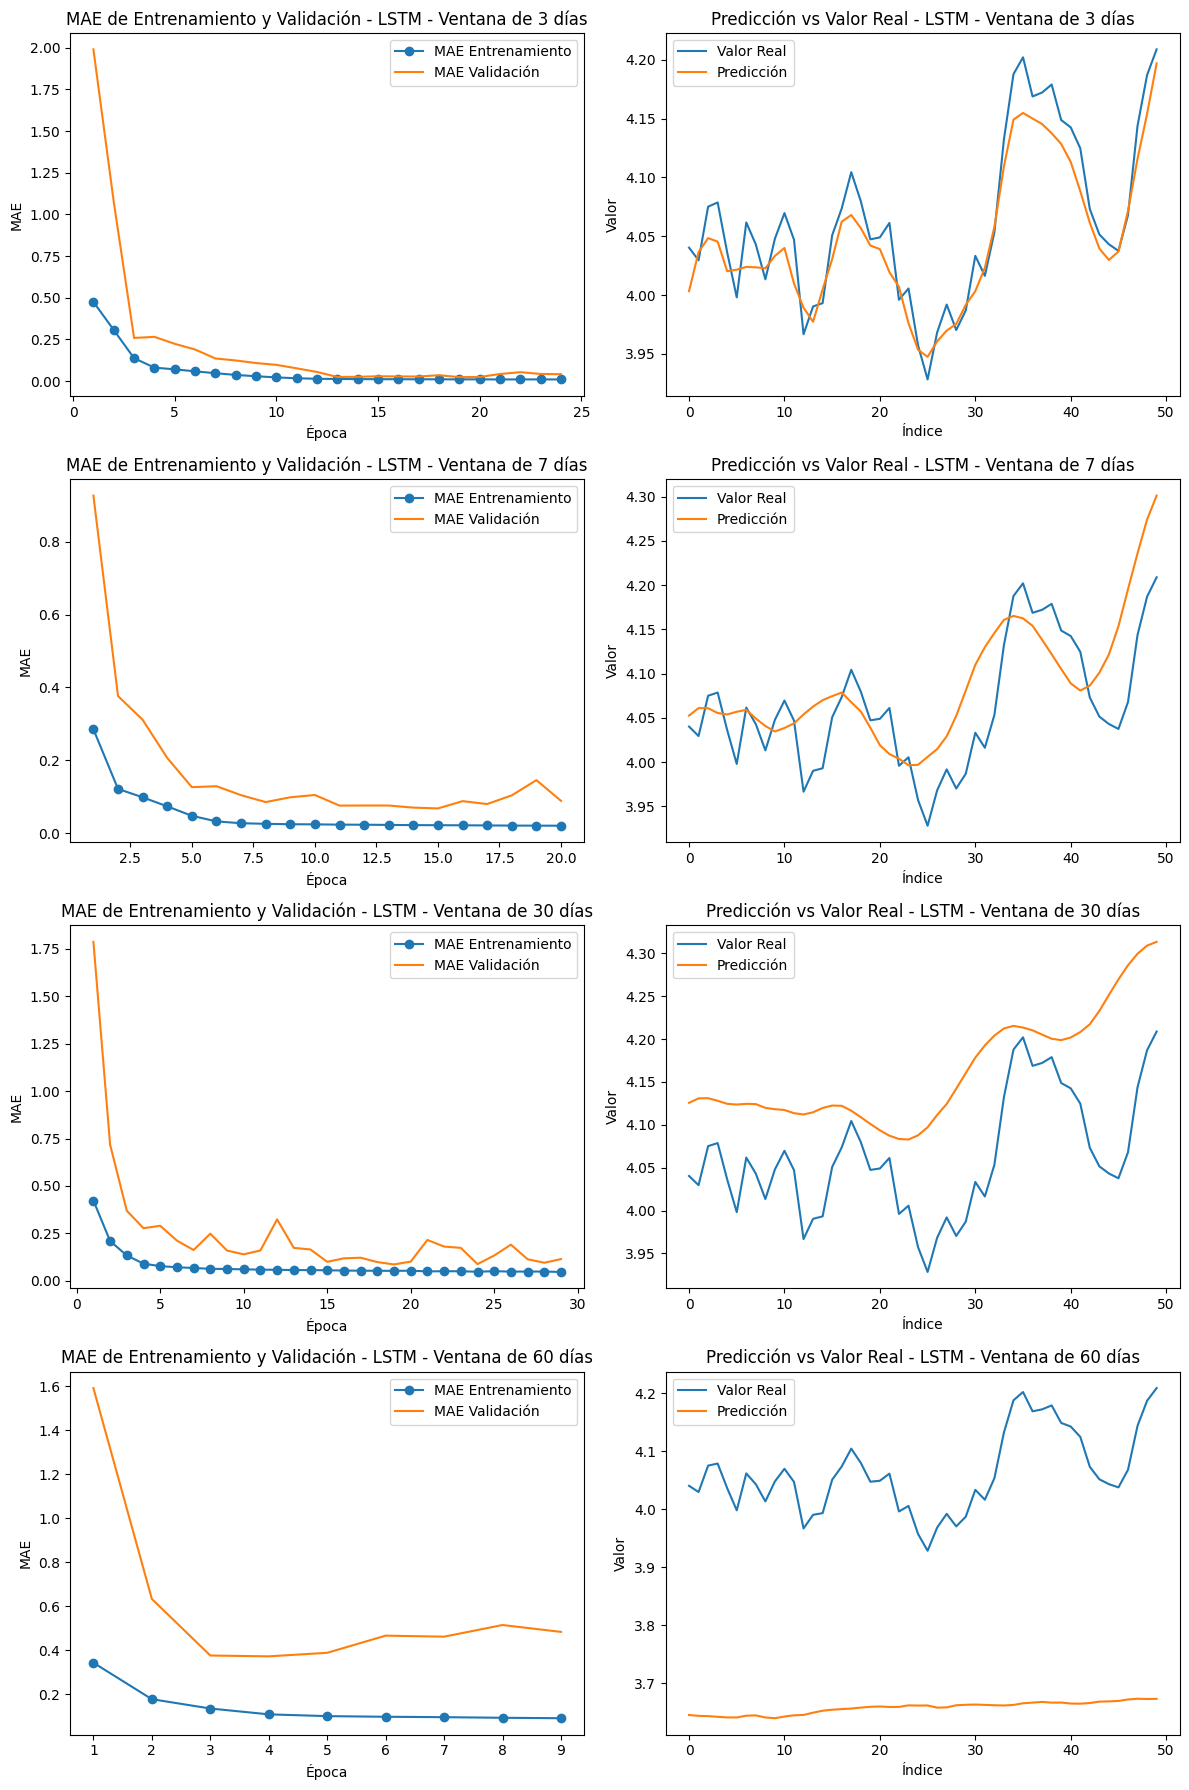

In [90]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

sequenceLSTM = [3,7,30,60]

for i, n in enumerate(sequenceLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Definir los nuevo dataset
  datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=True,
    batch_size=batch_size,
    start_index=0
  )
  
  datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
  )

  datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=n,
    shuffle=False,
    batch_size=batch_size,
    start_index=0
  )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(n, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=42,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Ventana de {n} días", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Ventana de {n} días", axes[i][1])

  print(f"MAE de prueba (Ventana de {n} días): {mae:.4f}")

plt.tight_layout()
plt.show()

Cambiando el Batch Size

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE de prueba (Batch Size 16): 0.8773
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE de prueba (Batch Size 32): 0.8093
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE de prueba (Batch Size 64): 0.8633
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE de prueba (Batch Size 128): 0.8376


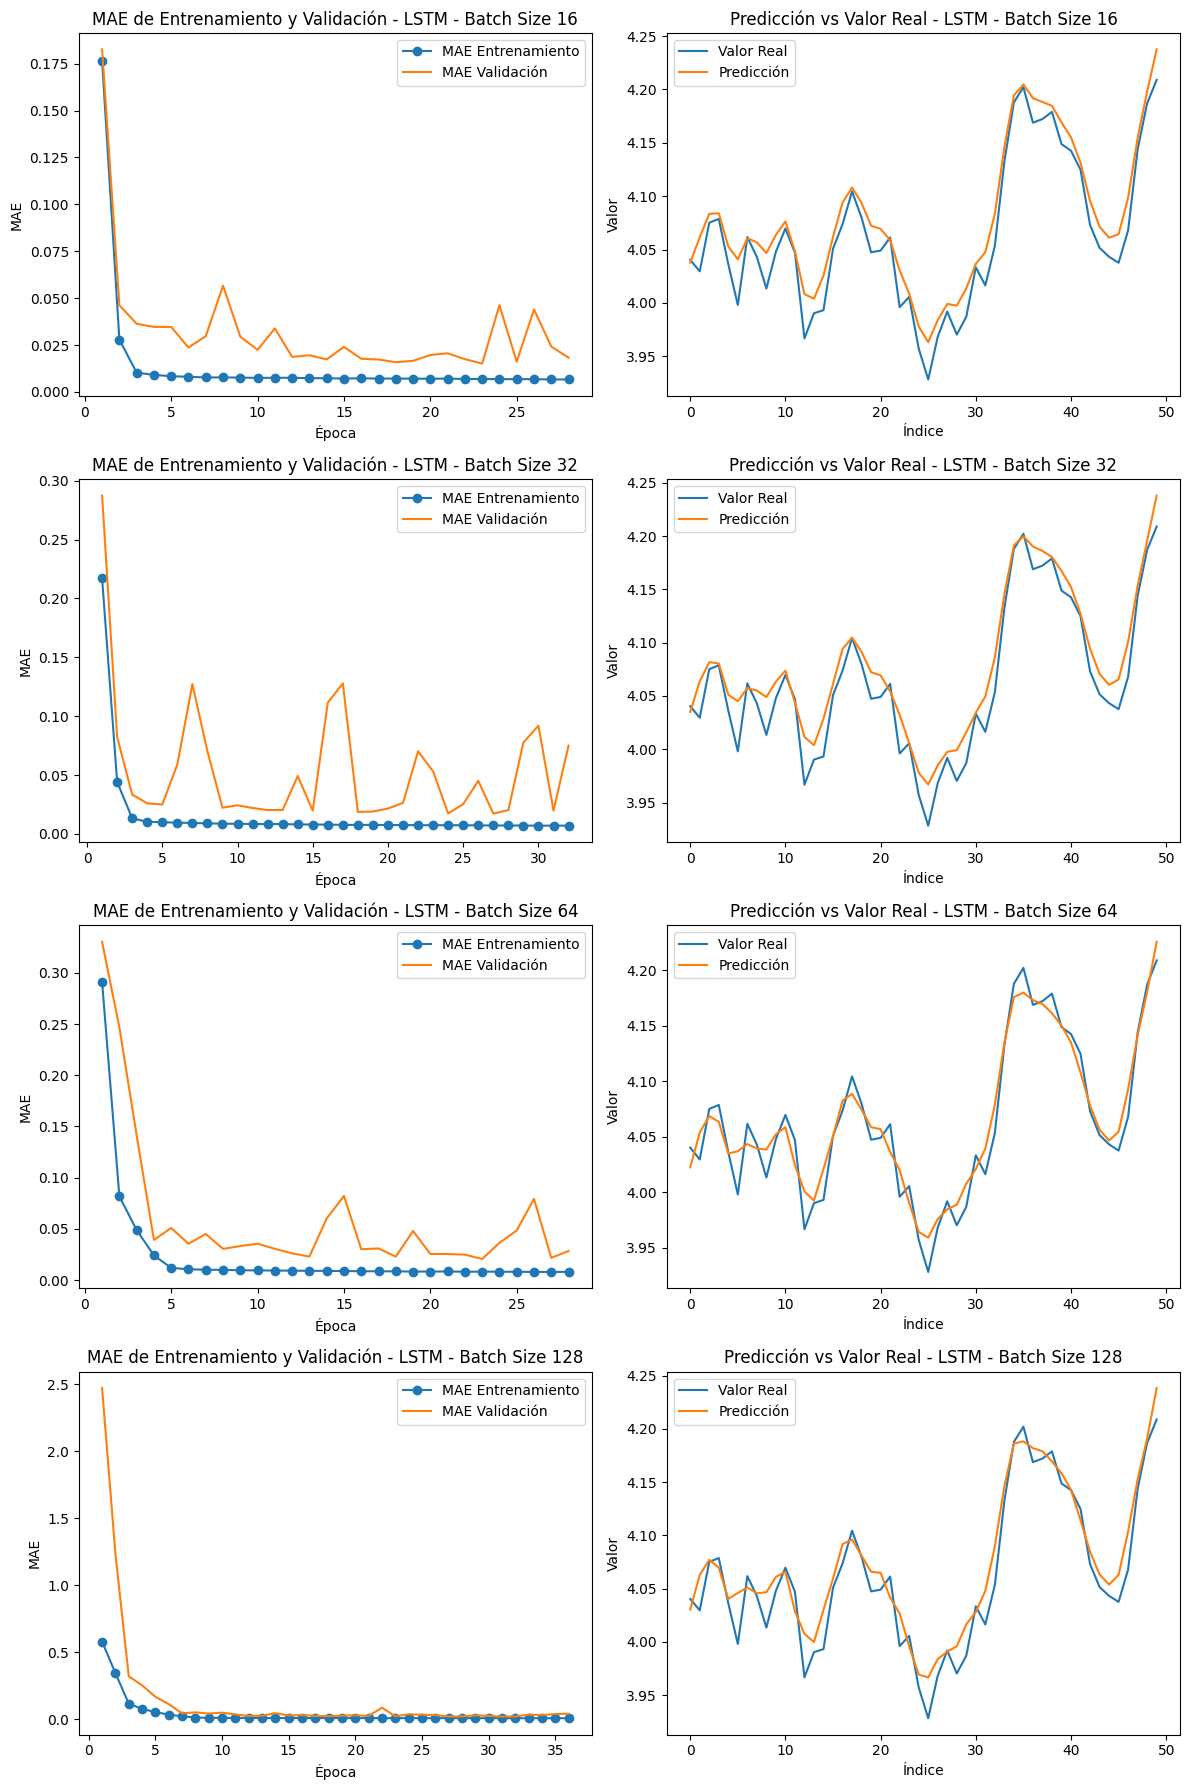

In [91]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

batchLSTM = [16,32,64,128]

for i, n in enumerate(batchLSTM):
  #Limpiar sesión
  tf.keras.backend.clear_session()
  
  #Definir los nuevo dataset
  datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
    data = train2D[:-delay],
    targets=train2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=True,
    batch_size=n,
    start_index=0
  )
  
  datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
    data = validation2D[:-delay],
    targets=validation2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=False,
    batch_size=n,
    start_index=0
  )

  datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
    data = test2D[:-delay],
    targets=test2D[delay:],
    sampling_rate=sampling_rate,
    sequence_length=3,
    shuffle=False,
    batch_size=n,
    start_index=0
  )
  
  #Crear el modelo 
  inputs = keras.Input(shape=(3, 1))
  x = layers.LSTM(15)(inputs)
  outputs = layers.Dense(1)(x)
  modelo = keras.Model(inputs, outputs)
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    
  
  history = modelo.fit(
    datasetTrainLSTM,
    epochs=42,
    validation_data=datasetValidationLSTM,
    callbacks=cb,
    verbose=0   
  )
  
  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
  pred = modelo.predict(datasetTestLSTM)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Batch Size {n}", axes[i][0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Batch Size {n}", axes[i][1])

  print(f"MAE de prueba (Batch Size {n}): {mae:.4f}")

plt.tight_layout()
plt.show()

**Configuración con mejores resultados**

Cantidad de Neuronas = 15

Épocas = Entre 34 y 42 (early stopping)

Sequence Length = 3 días

Batch Size = 32

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE de prueba - Mejores Resultados): 0.9102


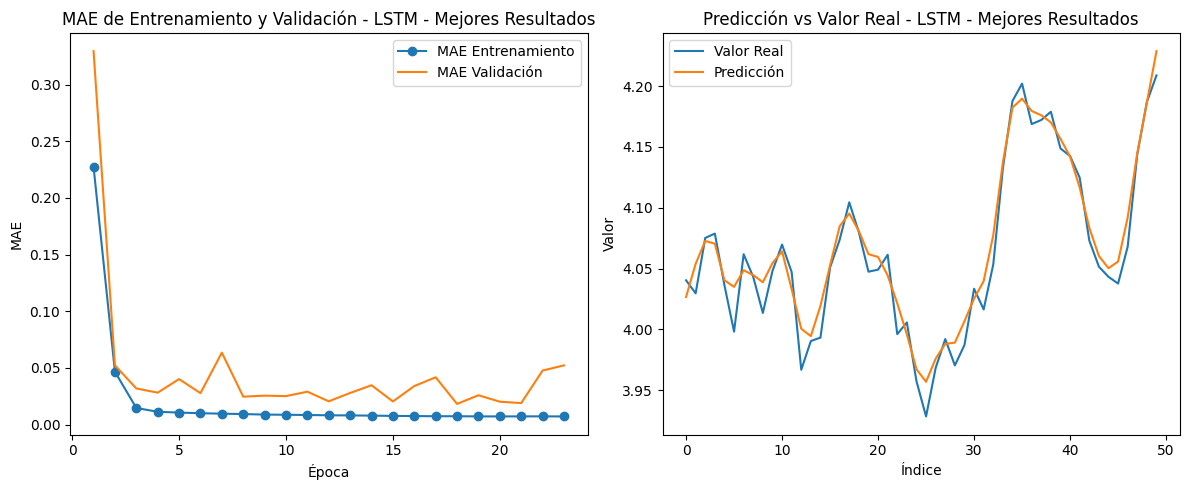

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Definir los nuevo dataset
datasetTrainLSTM = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=True,
  batch_size=32,
  start_index=0
)

datasetValidationLSTM = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=False,
  batch_size=32,
  start_index=0
)

datasetTestLSTM = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=3,
  shuffle=False,
  batch_size=32,
  start_index=0
)

#Crear el modelo 
inputs = keras.Input(shape=(3, 1))
x = layers.LSTM(15)(inputs)
outputs = layers.Dense(1)(x)
modelo = keras.Model(inputs, outputs)

#Entrenar el modelo
cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    

history = modelo.fit(
  datasetTrainLSTM,
  epochs=42,
  validation_data=datasetValidationLSTM,
  callbacks=cb,
  verbose=0   
)

#Evaluar el modelo
mae = modelo.evaluate(datasetTestLSTM, verbose=0)[1]
pred = modelo.predict(datasetTestLSTM)  
graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - Mejores Resultados", axes[0])
graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - Mejores Resultados", axes[1])

print(f"MAE de prueba - Mejores Resultados): {mae:.4f}")

plt.tight_layout()
plt.show()

## 3) Modelo GRU

Definir la arquitectura

In [ ]:
inputsGRU = keras.Input(shape=(sequence_length, 1))
xGRU = layers.GRU(64)(inputsGRU) 
outputsGRU = layers.Dense(1)(xGRU)
GRUBase = keras.Model(inputsGRU, outputsGRU)

Entrenar el modelo

In [ ]:
GRUBase.compile(optimizer="adam", loss="mse", metrics=["mae"])
callbacksGRU = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

historyGRU = GRUBase.fit(
    datasetTrain,
    epochs=20,
    validation_data=datasetValidation,
    callbacks=callbacksGRU
)

print(f"MAE de las pruebas - GRU: {GRUBase.evaluate(datasetTest)[1]:.2f}")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1700 - mae: 0.1949 - val_loss: 0.0888 - val_mae: 0.2150
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0120 - mae: 0.0530 - val_loss: 0.0465 - val_mae: 0.1677
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0086 - mae: 0.0486 - val_loss: 0.0395 - val_mae: 0.1562
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0078 - mae: 0.0488 - val_loss: 0.0421 - val_mae: 0.1695
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0071 - mae: 0.0483 - val_loss: 0.0311 - val_mae: 0.1388
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0064 - mae: 0.0468 - val_loss: 0.0250 - val_mae: 0.1196
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0057 - mae: 0.0453 - val_loss: 0.0235 - val_mae: 0.1210
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0048 - mae: 0.0430 - val_loss: 0.0185 - val_mae: 0.1062
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.004

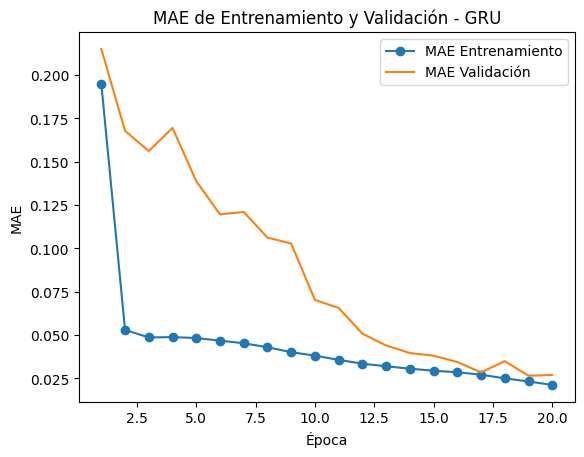

In [ ]:
graficaeMAE(historyGRU, "MAE de Entrenamiento y Validación - GRU")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


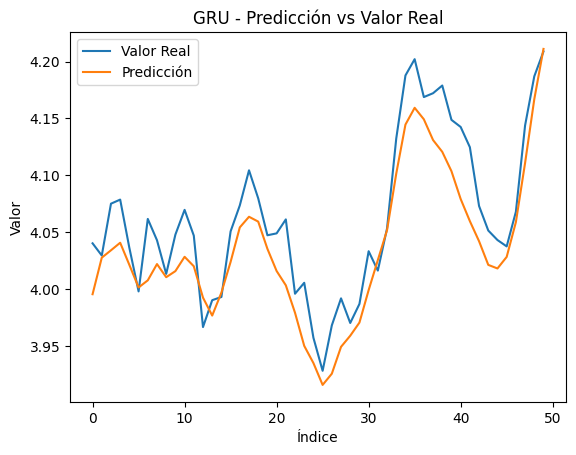

In [ ]:
prediccionGRU = GRUBase.predict(datasetTest)
y = np.concatenate([y for x, y in datasetTest], axis=0) 

graficarPrediccion(prediccionGRU, y, "GRU - Predicción vs Valor Real")